In [3]:
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR
import pickle
import numpy as np
import keras
import robot_vlp.data.preprocessing as p
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

2024-10-31 08:21:54.707 | INFO     | robot_vlp.config:<module>:11 - PROJ_ROOT path is: /Users/tyrelglass/PhD/Repositories/robot-vlp


In [49]:
import robot_vlp.data.preprocessing as p
import robot_vlp.data.path_generation as pg
def load_run_data(filter_params):
    test_files = p.path_filter(filter_params, mode = 'include')
    X_data, y_data = p.load_data(test_files)
    return X_data, y_data

In [120]:
plot_params = {
    'start_index':0,
    'path_length':113,
    'filter_params':{
        'n':'n_4',
        'direction':'_clockwise',
        'vlp_acc':'high_acc', 
        'odo_acc':'err_3', 
        'run':'run1'
    }
}
X_data, y_data = load_run_data(plot_params['filter_params'])

arr = X_data[0]
win_len = 10
lst = []
for i in range(len(arr) - win_len):
    lst.append(arr[i:i+win_len, :])
X_all = np.array(lst)

X_scaler = p.build_scaler()

X_all_scaled = p.apply_scaler(X_all, X_scaler)



In [121]:
from robot_vlp.config import MODELS_DIR
def ang_loss_fn(y_true, y_pred):
    return keras.losses.cosine_similarity(y_true, y_pred) + 1

model = keras.models.load_model(MODELS_DIR / 'model_02.keras',custom_objects={"ang_loss_fn": ang_loss_fn})

In [122]:
pre = model.predict(X_all_scaled)

x_pre = pre[0][:,0]
y_pre = pre[0][:,1]
ang_pre = p.vector_to_ang(pre[1], unit = 'degrees').numpy()

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/stepWARNING:tensorflow:5 out of the last 21 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x30a9f3250> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


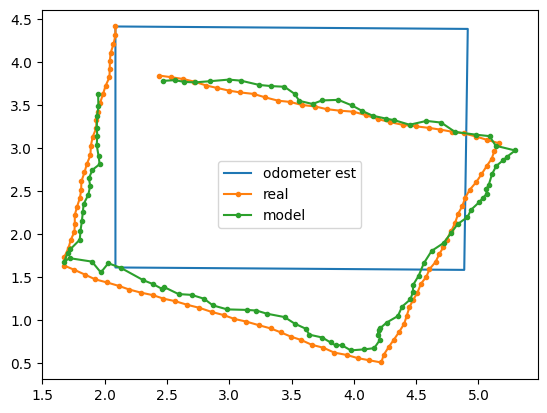

In [123]:
b = plot_params['start_index']
e = plot_params['path_length'] + b
plt.plot(X_data[0][b:e,0], X_data[0][b:e,1], label = 'odometer est')
plt.plot(y_data[0][b:e,0], y_data[0][b:e,1], marker = '.', label = 'real')
plt.plot(x_pre[b:e - 10], y_pre[b:e - 10], marker = '.', label = 'model')
plt.legend()

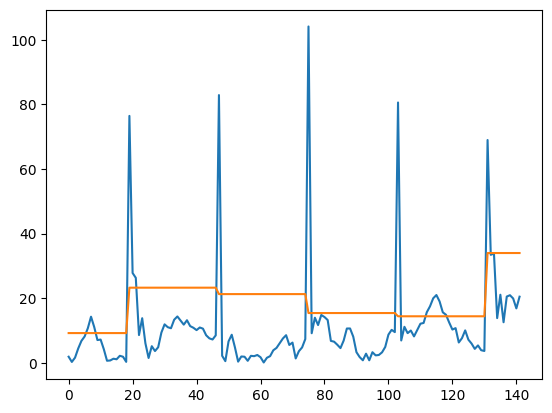

In [124]:
real_ang = y_data[0][10:,2]
odo_ang = X_data[0][10:,2]

pre_err = real_ang - ang_pre
odo_err = real_ang - odo_ang

pre_err = ((pre_err + 180)%360)-180
odo_err = ((odo_err + 180)%360)-180



plt.plot(np.abs(pre_err))
plt.plot(np.abs(odo_err))
# plt.plot(lst)

# plt.axhline(180, c = 'r')
# plt.axhline(-180, c = 'r')
# plt.axhline(-360, c = 'r')

In [96]:

lst = []
for i in range(len(pre_err)):
    err = pre_err[i]
    if err > 180:
        err = err - 360
    elif err < -180:
        err = err + 360
    lst.append(err)

In [88]:
-200%360

160

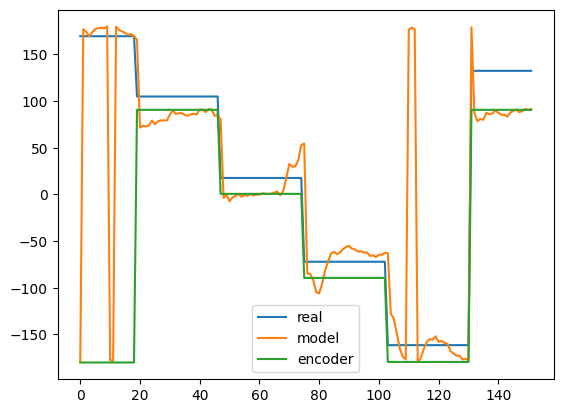

In [76]:
plt.plot(y_data[0][10:,2], label = 'real')
plt.plot(ang_pre, label = 'model')
plt.plot(X_data[0][10:,2], label = 'encoder')

plt.legend()


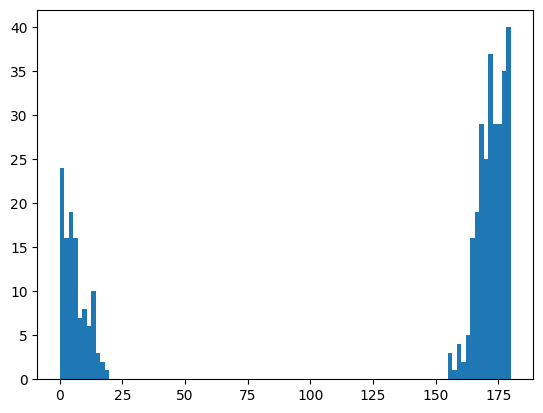

In [99]:
_= plt.hist((y_full[10:,2][:-1] - p.vector_to_ang(ang_pre, unit = 'degrees').numpy()[1:])%180 , bins = 100)


In [50]:
from robot_vlp.config import MODELS_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, TRAINING_LOGS_DIR

In [49]:
import keras_tuner as kt

In [51]:
import tensorflow as tf

In [53]:
def ang_loss_fn(y_true, y_pred):
    return keras.losses.cosine_similarity(y_true, y_pred) + 1

In [54]:
with open(PROCESSED_DATA_DIR/'data.pickle', 'rb') as handle:
    data = pickle.load(handle)

In [57]:
random_search_tuner = kt.RandomSearch(
    build_model, objective='val_loss', max_trials = 52, overwrite = False,
    directory = TRAINING_LOGS_DIR, project_name = "rnn_rnd_search", seed = 42 
)

Reloading Tuner from /Users/tyrelglass/PhD/Repositories/robot-vlp/models/training_logs/rnn_rnd_search/tuner0.json


In [58]:
random_search_tuner.search(x = data['X_train'],
                            y = [data['y_train'][:,[0,1]],  p.ang_to_vector(data['y_train'][:,2], unit = 'degrees').numpy()],
                            epochs = 10,
                            validation_data = (data['X_valid'], [data['y_valid'][:,[0,1]], p.ang_to_vector(data['y_valid'][:,2], unit = 'degrees').numpy()]) 
                            )

Trial 52 Complete [00h 03m 17s]
val_loss: 0.08797971904277802

Best val_loss So Far: 0.04042275622487068
Total elapsed time: 13h 40m 03s


In [52]:
def build_model(hp):
    n_hidden = hp.Int('n_hidden', min_value = 0, max_value = 8, default = 2)
    n_neurons = hp.Int('n_neurons', min_value = 1, max_value = 256)
    learning_rate = hp.Float('learning_rate', min_value = 1e-4, max_value = 1e-2, sampling = 'log')
    optimizer = hp.Choice('optimizer', values = ['sgd', 'adam'])

    if optimizer == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer =  tf.keras.optimizers.Adam(learning_rate=learning_rate)

    

    input_ = keras.layers.Input(shape=(None, 5))


    next_input = input_
    if n_hidden == 0:
        last_hidden_layer = input_

    else:
        for i in range(n_hidden - 1):
            hidden_layer = keras.layers.SimpleRNN(n_neurons, return_sequences= True)(next_input)
            next_input = hidden_layer

        last_hidden_layer = keras.layers.SimpleRNN(n_neurons, return_sequences= False)(next_input)
 

    # hidden1 = keras.layers.SimpleRNN(20, return_sequences=True)(input_)
    # hidden2 = keras.layers.SimpleRNN(20)(hidden1)

    out1 = keras.layers.Dense(2, name='pos')(last_hidden_layer)
    out2 = keras.layers.Dense(2, name='heading')(last_hidden_layer)

    model = keras.Model(inputs = [input_], outputs = [out1,out2])

    model.compile(optimizer=optimizer,
            loss = ['mse',ang_loss_fn],
                loss_weights = [1., 1.],
            )
    return model

